# Importy

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, BatchNormalization 
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam, AdamW, SGD, RMSprop
from keras.utils import to_categorical
from keras.regularizers import L2, L1, L1L2

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, auc, roc_auc_score, precision_score, recall_score, accuracy_score #report klasyfikacji / macierz pomyłek / jej wyświetlenie


import matplotlib.pyplot as plt

from math import sqrt 

# EDA

In [24]:
# Wczytaj dane
X = pd.read_csv("../Dane/latin_data.csv", header=None)
y = pd.read_csv("../Dane/latin_label.csv", header=None)

X = np.array(X, dtype=np.float32)
y = np.array(y).ravel()

In [25]:
print("Kształt X:", X.shape) 
print("Kształt y:", y.shape)
print("Przykładowe etykiety:", y[:5])


Kształt X: (12822, 784)
Kształt y: (12822,)
Przykładowe etykiety: [0 0 0 0 0]


Jeden obrazek składa się z 784 pikseli oraz są kwadratowe tzn. obrazy są rozmiarów 28 x 28.

In [26]:
img_size = 28

Potrzebna lista liter, żeby etykiety nie były cyframi, tylko bardziej opisowe

In [27]:
letters = np.array(list(string.ascii_uppercase))
y_letters = letters[y]

In [28]:
unique, counts = np.unique(y, return_counts=True)
unique_letters = letters[unique]
for u, c in zip(unique_letters, counts):
    print(f"Etykieta {u}: {c} próbek")


Etykieta A: 493 próbek
Etykieta B: 496 próbek
Etykieta C: 508 próbek
Etykieta D: 461 próbek
Etykieta E: 500 próbek
Etykieta F: 482 próbek
Etykieta G: 509 próbek
Etykieta H: 509 próbek
Etykieta I: 476 próbek
Etykieta J: 458 próbek
Etykieta K: 460 próbek
Etykieta L: 523 próbek
Etykieta M: 547 próbek
Etykieta N: 521 próbek
Etykieta O: 465 próbek
Etykieta P: 526 próbek
Etykieta Q: 484 próbek
Etykieta R: 470 próbek
Etykieta S: 519 próbek
Etykieta T: 477 próbek
Etykieta U: 475 próbek
Etykieta V: 480 próbek
Etykieta W: 465 próbek
Etykieta X: 490 próbek
Etykieta Y: 545 próbek
Etykieta Z: 483 próbek


Posiadamy zbiór 26 liter łacińskich.

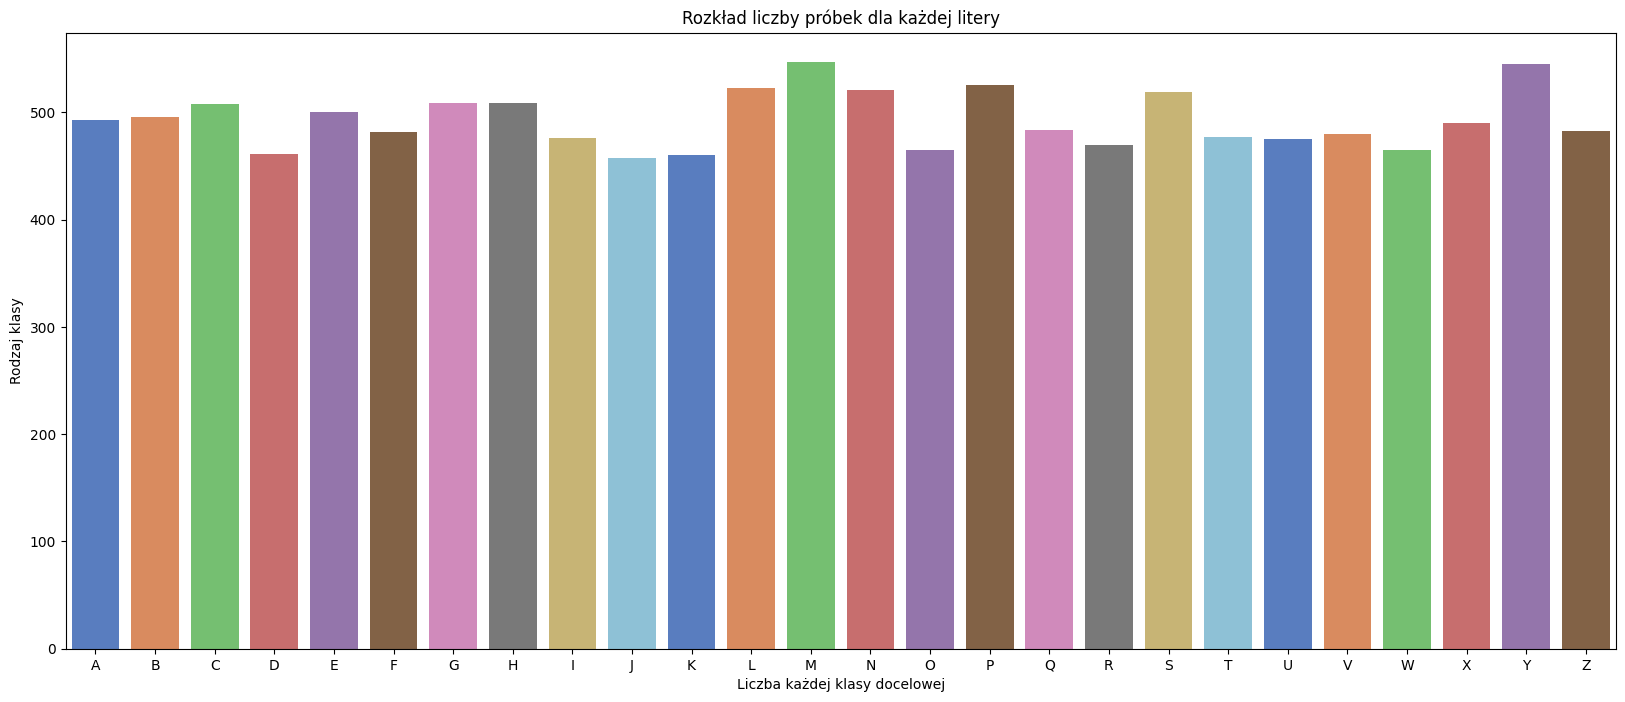

In [29]:
plt.figure(figsize=(20, 8))
sns.countplot(x=y_letters, palette='muted', hue=y)
plt.xlabel('Liczba każdej klasy docelowej')
plt.ylabel("Rodzaj klasy")
plt.title('Rozkład liczby próbek dla każdej litery')
plt.legend().set_visible(False)
plt.show()

Sprawdźmy czy wartości pikseli w obrazach są znormalizowane.

Min piksel: 0.0
Max piksel: 1.0


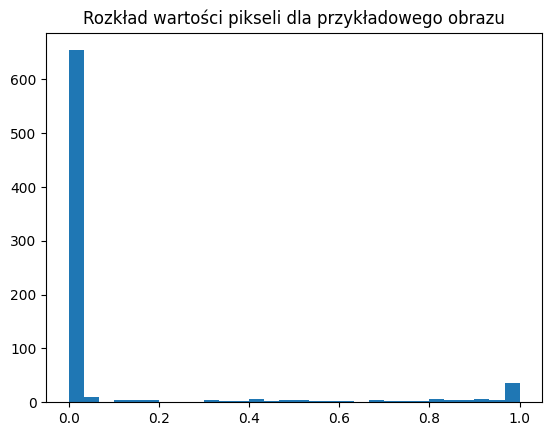

In [30]:
print("Min piksel:", X.min())
print("Max piksel:", X.max())

plt.hist(X[0], bins=30)
plt.title("Rozkład wartości pikseli dla przykładowego obrazu")
plt.show()


Są znormalizowane - dobrze 

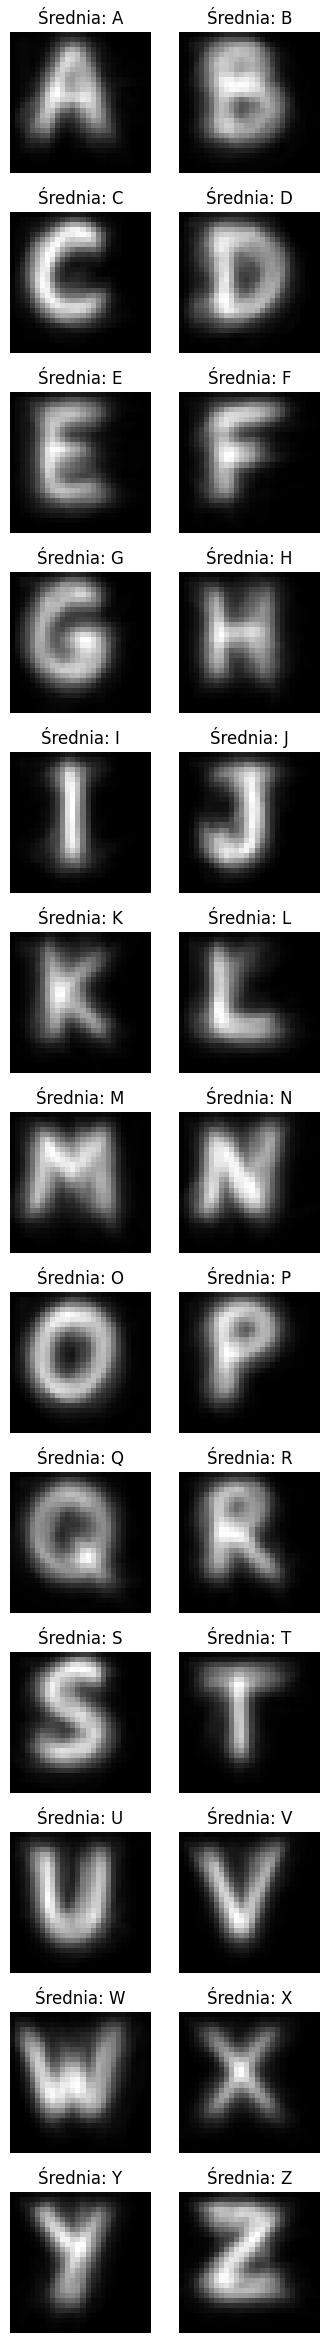

In [31]:
mean_images = []
for label in np.unique(y):
    mean_img = X[y == label].mean(axis=0).reshape(img_size, img_size)
    mean_images.append(mean_img)

plt.figure(figsize=(4, 30))
for i, (label, img) in enumerate(zip(unique_letters, mean_images)):
    plt.subplot(13, 2, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Średnia: {label}")
    plt.axis('off')
plt.show()

## Przykładowe obrazy litery łacińskiej A - wizualizacja różnych przykładów

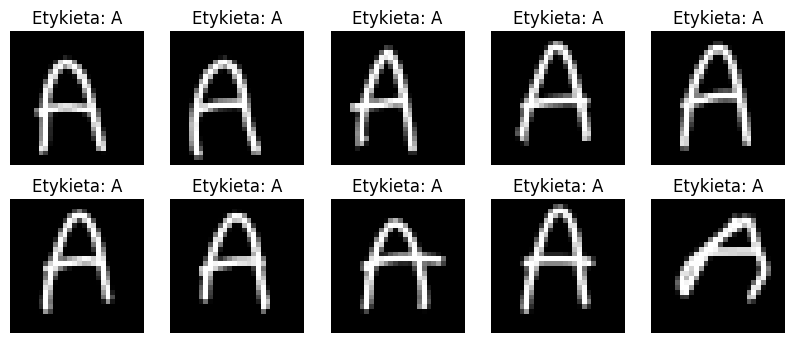

In [32]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(img_size, img_size), cmap='gray')
    plt.title(f"Etykieta: {unique_letters[y[i]]}")
    plt.axis('off')
plt.show()

# Sieci neuronowe typu perceptronowego z algorytmem uczenia typu BP

## Funckje pomocnicze

In [33]:
def narysuj_wykres_epochy_nn(history_t):
    train_loss = history_t.history['loss']
    val_loss = history_t.history['val_loss']
    train_acc = history_t.history['accuracy']
    val_acc = history_t.history['val_accuracy']

    epochs = range(1, len(train_loss) + 1)

    # Wykres strat
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label='Loss - training')
    plt.plot(epochs, val_loss, label='Loss - test')
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Wykres dokładności
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label='Accuracy - training')
    plt.plot(epochs, val_acc, label='Accuracy - test')
    plt.title('Accuracy vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

## Callbacki sieci neuronowej

Stosuje funkcje, gdyż chce mieć możliwość ustalenia własnych wartości domyślnych, inne niż zaproponowane w tych klasach. Umożliwia mi to zarazem dowolną modyfikacje tych parametrów.

In [34]:
def early_stopping(monitor='loss', patience=10, restore_best_weights=True, verbose = 1, start_from_epoch=2):
    return EarlyStopping( 
                        monitor=monitor,
                        patience=patience,
                        restore_best_weights=restore_best_weights,
                        verbose = verbose,
                        start_from_epoch=start_from_epoch
                    )
    
def reduce_lr(  monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-9,
                verbose=1,
                cooldown = 2):
    
    return ReduceLROnPlateau(
                monitor=monitor,
                factor=factor,
                patience=patience,
                min_lr=min_lr,
                verbose=verbose,
                cooldown = cooldown
            )   

## Sieci Neuronowe

Train/test/val split

In [35]:
y_unique_values = np.unique(y)
y_classes_num = len(y_unique_values) #26

y = to_categorical(y, num_classes = y_classes_num)

X_train, X_val, y_train, y_val = train_test_split(X,y, train_size=0.7, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val,y_val, train_size=0.5, random_state=42)



In [36]:
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (8975, 784)
X_val shape: (1923, 784)
X_test shape: (1924, 784)


In [37]:
model = Sequential([
    Input(shape=(X_train.shape[1], ) ),
    
    Dense(512, activation='elu', kernel_regularizer=L2(1e-5)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(256, activation='leaky_relu', kernel_regularizer=L2(1e-5),
    bias_regularizer=L2(1e-4),
    activity_regularizer=L2(1e-5)),
    Dropout(0.1),
    
       
    Dense(128, activation='leaky_relu', kernel_regularizer=L2(1e-5),
    bias_regularizer=L2(1e-4),
    activity_regularizer=L2(1e-5)),

  
    Dense(64, activation='leaky_relu', kernel_regularizer=L2(1e-5),
    bias_regularizer=L2(1e-4),
    activity_regularizer=L2(1e-5)),
    
    
    Dense(32, activation='leaky_relu', kernel_regularizer=L2(1e-5),
    bias_regularizer=L2(1e-4),
    activity_regularizer=L2(1e-5)),
    
    Dense(y_classes_num, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001  ), #, weight_decay = 1e-5
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [38]:
epochs = 300

history_nn = model.fit(
    X_train, y_train,
    epochs=epochs,
    verbose=1,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks = [reduce_lr(patience=5), early_stopping(patience =15)]
)



Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4575 - loss: 2.3411 - val_accuracy: 0.4940 - val_loss: 2.2242 - learning_rate: 0.0010
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6855 - loss: 1.5419 - val_accuracy: 0.7010 - val_loss: 1.4410 - learning_rate: 0.0010
Epoch 3/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7600 - loss: 1.2249 - val_accuracy: 0.7650 - val_loss: 1.1590 - learning_rate: 0.0010
Epoch 4/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7994 - loss: 1.0239 - val_accuracy: 0.7868 - val_loss: 1.0564 - learning_rate: 0.0010
Epoch 5/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8286 - loss: 0.9022 - val_accuracy: 0.7977 - val_loss: 0.9816 - learning_rate: 0.0010
Epoch 6/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8500 - loss: 0.7903 - val_accuracy: 0.8138 - val_loss: 0.9301 - learning_rate: 0.0010
Epoch 7/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8704 - loss: 0.

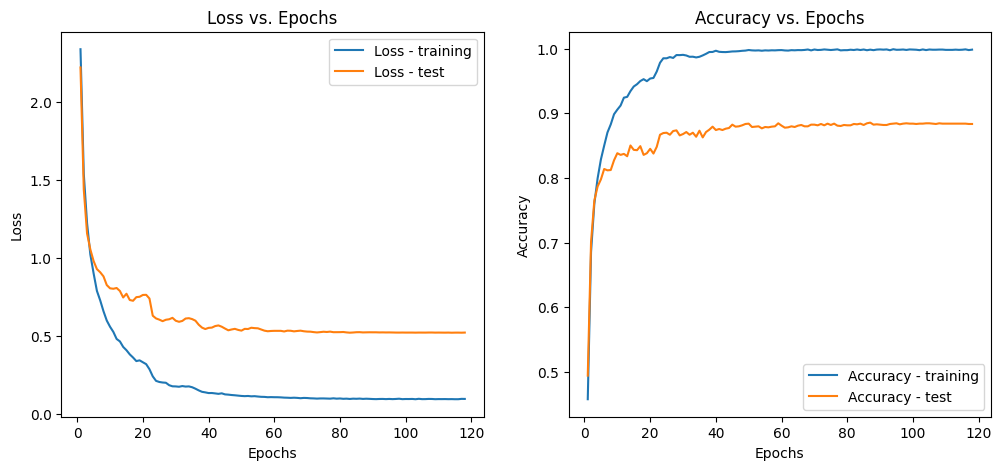

In [39]:
narysuj_wykres_epochy_nn(history_nn)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
==== Raport klasyfikacji ====
              precision    recall  f1-score   support

           0       0.88      0.91      0.90        91
           1       0.77      0.89      0.83        73
           2       0.88      0.87      0.87        76
           3       0.85      0.92      0.89        63
           4       0.89      0.91      0.90        74
           5       0.90      0.92      0.91        77
           6       0.88      0.87      0.88        78
           7       0.87      0.84      0.85        79
           8       0.88      0.94      0.91        72
           9       0.91      0.87      0.89        70
          10       0.92      0.82      0.87        56
          11       0.95      0.86      0.90        97
          12       0.89      0.91      0.90        92
          13       0.83      0.90      0.86        78
          14       0.78      0.82      0.80        55
          15       0.89      0.93      0.91        75
          16

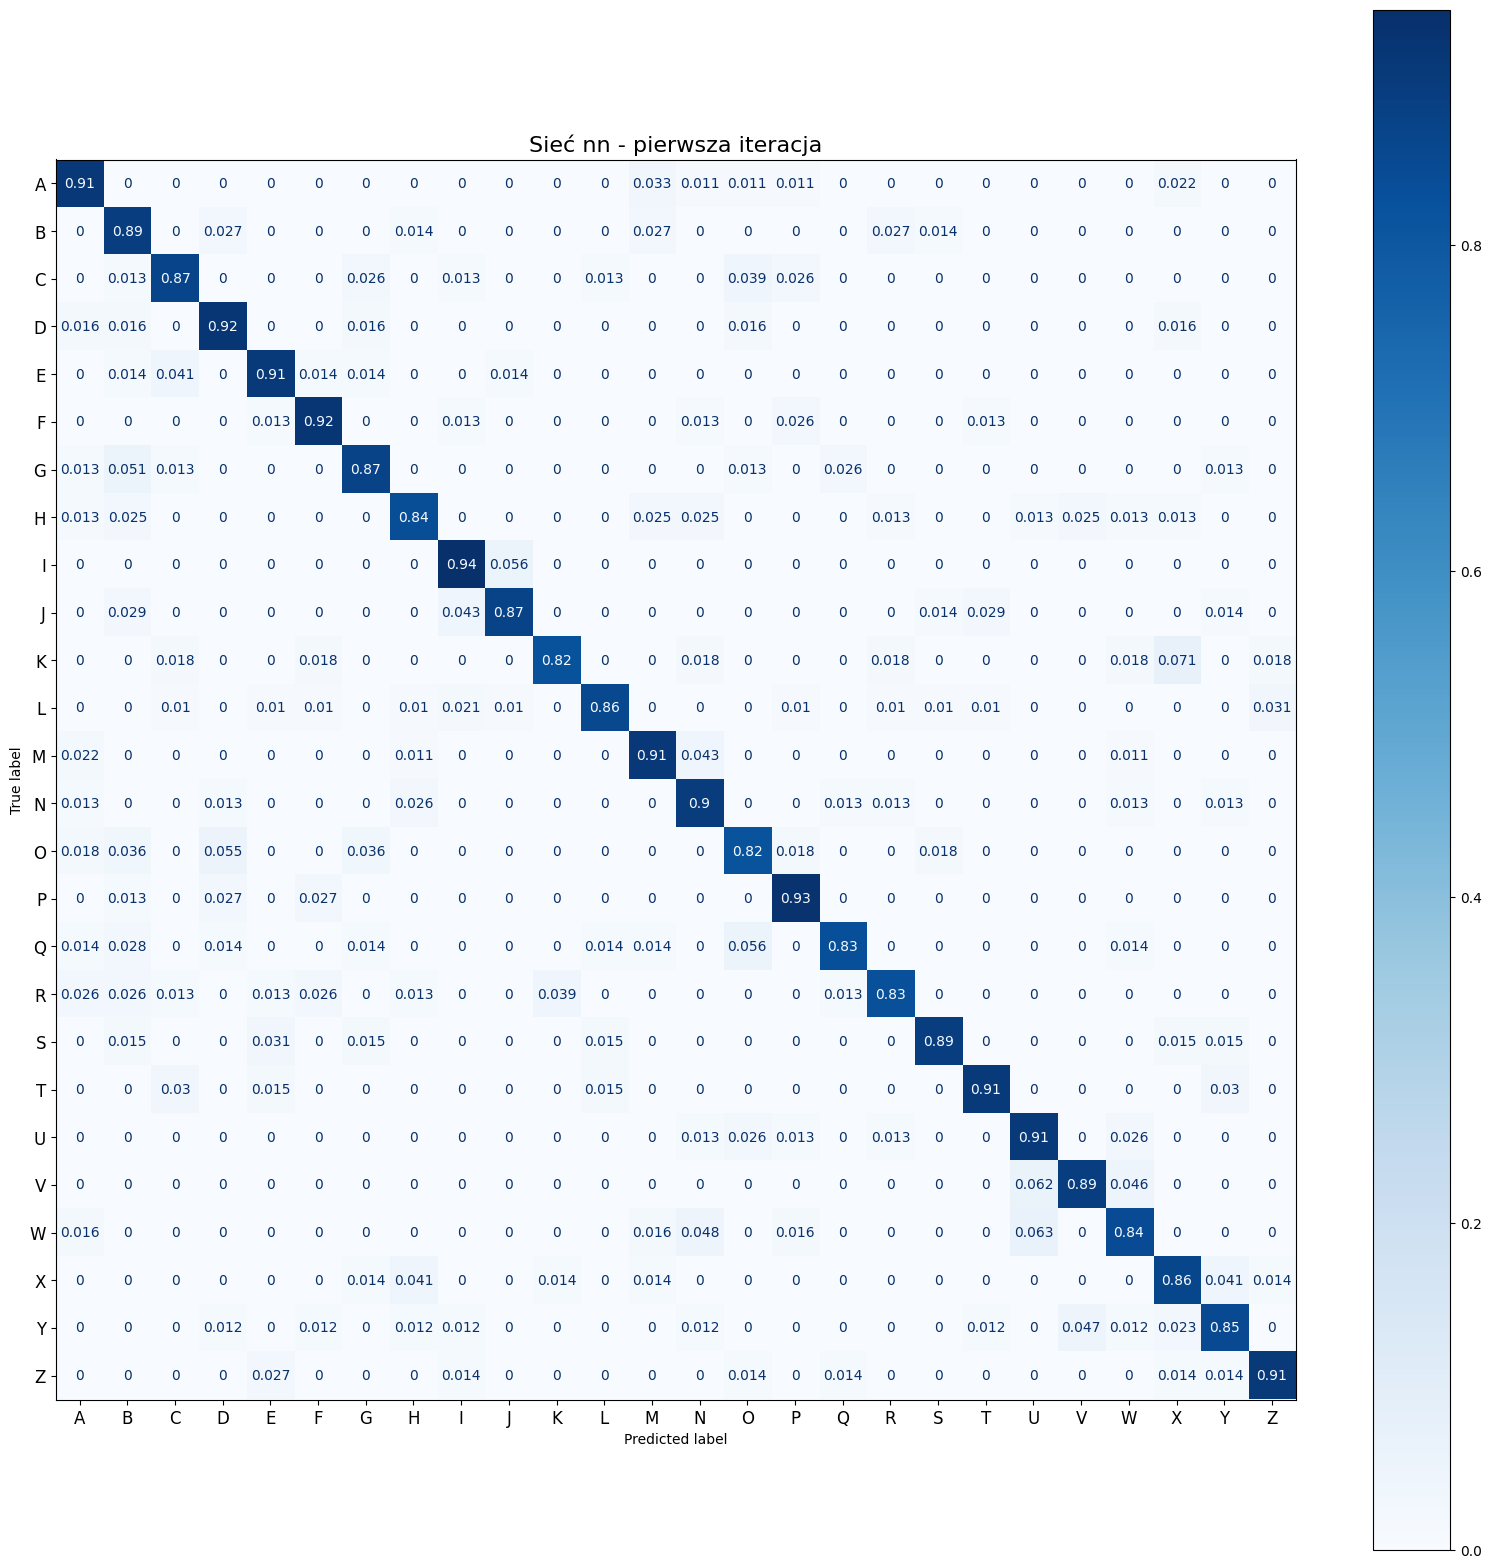

In [40]:
y_pred = model.predict(X_test)
y_pred_max = np.argmax(y_pred, axis=1)
y_test_max = np.argmax(y_test, axis=1)

print("==== Raport klasyfikacji ====")
print("=============================")
        
report = classification_report(y_test_max, y_pred_max)
print(report)
        
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
matrix = confusion_matrix(y_test_max, y_pred_max, normalize='true')
plt.figure(figsize=(20, 20))  # ustalenie czytelnego rozmiaru wykresu

disp = ConfusionMatrixDisplay(matrix, display_labels=labels) #przekształcenie macierzy pomyłek z wersji tekstowej w wersje graficzną
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=True)

#zwiększenie czcionki, by wykres był czytelny
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for text in disp.text_.ravel():
    text.set_fontsize(10)


plt.title("Sieć nn - pierwsza iteracja", fontsize=16)
plt.show()